In [3]:
import numpy as np
import pandas as pd

In [4]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [8]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [9]:

df.dropna(inplace=True)

In [10]:
df.shape

(714, 3)

In [11]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [12]:
X =df.iloc[:,1:]
y =df.iloc[:,0]

In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [14]:
X_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [15]:

clf = DecisionTreeClassifier()

In [16]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [17]:
accuracy_score(y_test,y_pred)

0.6153846153846154

In [18]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6345266040688575)

In [19]:
kbin_age = KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')


In [20]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])

])

In [21]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)


In [22]:
trf.named_transformers_['first'].n_bins_

array([10])

In [23]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42, 14.  , 19.  , 22.  , 25.  , 28.5 , 32.  , 36.  , 42.  ,
              50.  , 80.  ])                                                ],
      dtype=object)

In [24]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]

})

In [29]:
output['age_labels'] = pd.cut(
    x=X_train['Age'],
    bins=trf.named_transformers_['first'].bin_edges_[0].tolist()
)
output ['fare_labels']=pd.cut(
    x=X_train['Fare'],
    bins=trf.named_transformers_['second'].bin_edges_[0].tolist()
)


In [31]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
38,18.0,1.0,18.0000,5.0,"(14.0, 19.0]","(15.75, 26.0]"
784,25.0,4.0,7.0500,0.0,"(22.0, 25.0]","(0.0, 7.75]"
218,32.0,6.0,76.2917,8.0,"(28.5, 32.0]","(51.479, 82.171]"
881,33.0,6.0,7.8958,2.0,"(32.0, 36.0]","(7.75, 7.896]"
281,28.0,4.0,7.8542,1.0,"(25.0, 28.5]","(7.75, 7.896]"


In [32]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [33]:
accuracy_score(y_test,y_pred2)


0.6223776223776224

In [35]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6303012519561815)

In [39]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)

    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])

    ])
    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title('Age')

    plt.subplot(122)
    plt.hist(['Fare'])
    plt.hist(X_trf[:,0],color='red')
    plt.title('After')
    plt.show()

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title('Before')

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title('After')
    plt.show()

0.6317488262910798


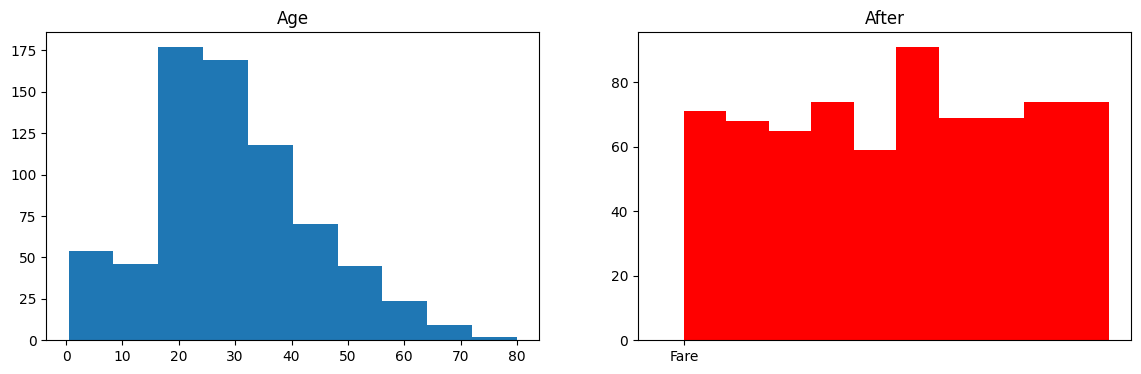

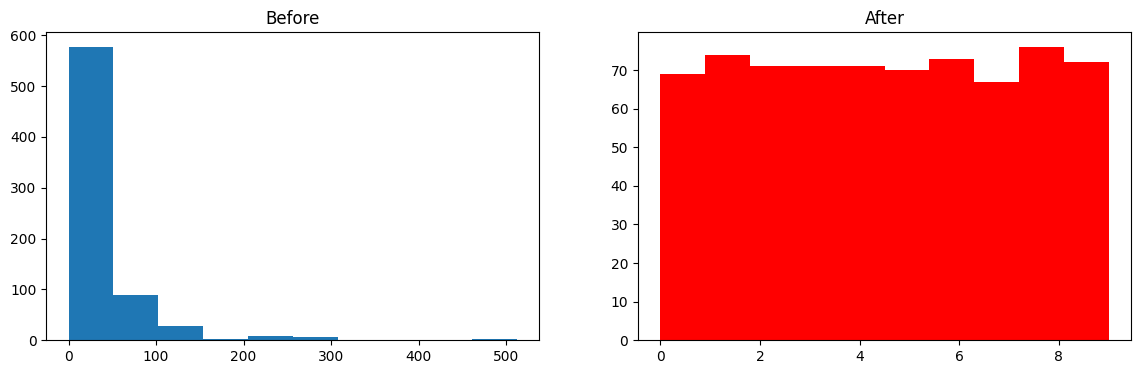

In [40]:
discretize(10,'quantile')

0.6302621283255085


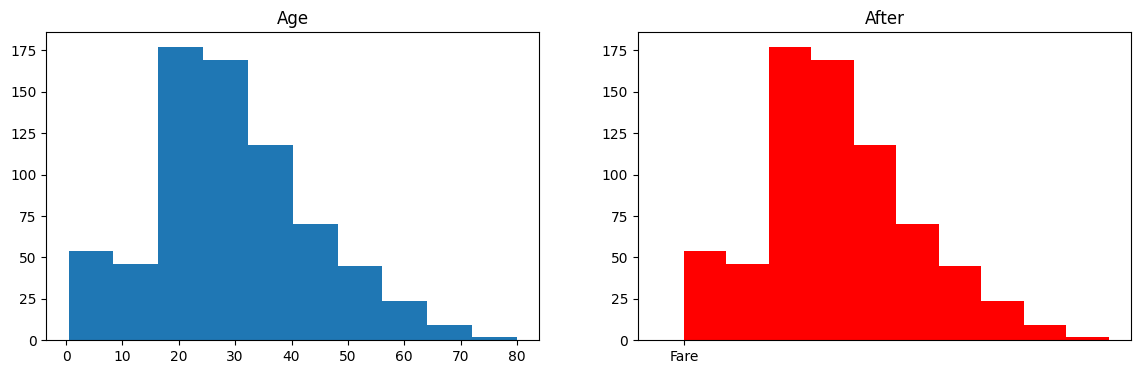

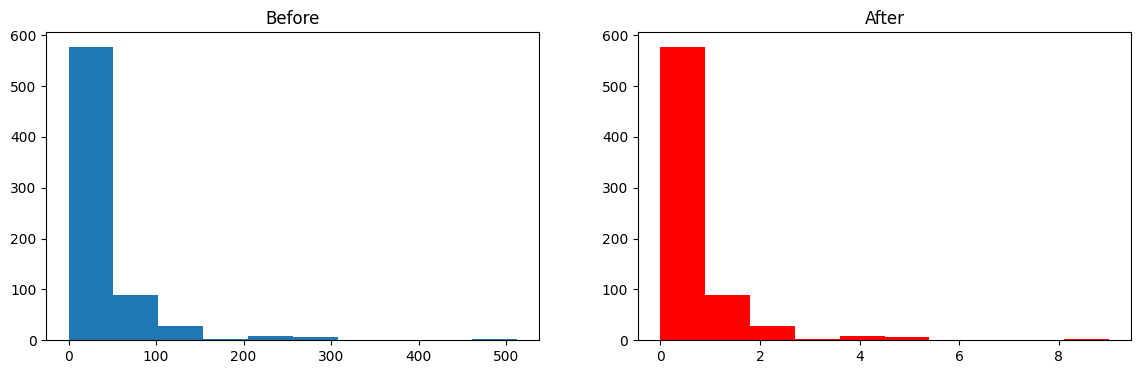

In [41]:
discretize(10,'uniform')

0.6345657276995305


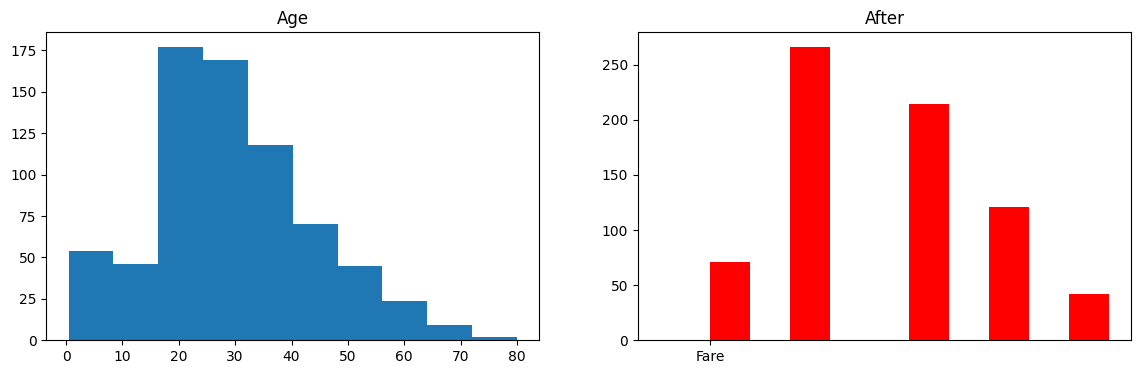

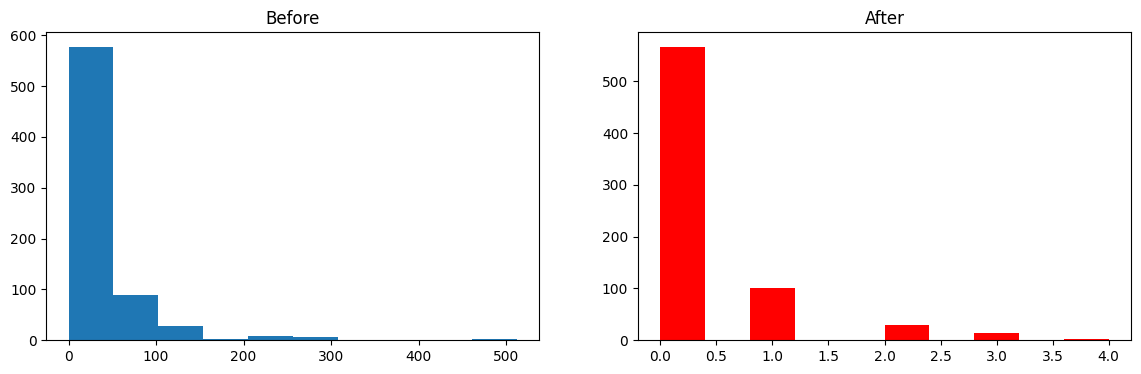

In [44]:
discretize(5,'kmeans')